In [1]:
import sys
import os

project_path = "/home/sagemaker-user/gbm_hackathon"
if project_path not in sys.path:
    sys.path.append(project_path)
    print(sys.path)

In [2]:
%load_ext autoreload
%autoreload 2
import os, sys
import pandas as pd
import numpy as np
import pickle as pkl
import torch
import seaborn as sns
import matplotlib.pyplot as plt 
import subprocess

from foundation.clinical import get_batch
from gbmhackathon.data import MosaicDataset
from gbmhackathon.s3_loader import load_s3, write_s3

In [3]:
%load_ext autoreload
%autoreload 2

from gbmhackathon.training.predictive import *
from gbmhackathon.models.mme import GBMNet
from gbmhackathon.utils.loss_functions import InfoNCELoss, RegularizedInfoNCELoss, SmoothingFunction, RankMe
from gbmhackathon.utils.module_functions import instantiate
from gbmhackathon.utils.analysis import prepare_embeddings
from gbmhackathon.s3_loader import load_s3

import os
from copy import deepcopy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# To investigate gradients
from torchviz import make_dot
from sklearn.ensemble import GradientBoostingClassifier
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torch.optim import Adam

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
from gbmhackathon import MosaicDataset, BruceDataset
from gbmhackathon.utils.model_saving import load_model, CPU_Unpickler
from gbmhackathon.models.mme import MultiModalEncoder, concat_modality_embeddings, ClinicalLinkageModule

In [5]:
torch.set_num_threads(16)
device = "cpu" #"cuda" if torch.cuda.is_available() else "cpu"
torch.set_default_device(device)

In [6]:
name_emb_dict = {"hne":"embeddings_HnE_OptimusH0.pkl",
"spatial":"2025-03-23_18-32_spatial_emb_V1.pkl",
"clinical":"2025-05-25_14-36_new_clinical_emb_V1.pkl",
"wes":"2025-04-05_13-40_wes_emb_V1.pkl",
"bulk":"2025-05-03_10-15_bulk_emb_V1.pkl",
"scRNA":"2025-05-04_02-35_scRNA_emb_V1.pkl"}
pkl_storage_folder = "embedding_V1"

In [7]:
dataset = PredictiveLearningDataset(name_emb_dict, pkl_storage_folder, device=device, dropout=1.0)
print(f"Dataset size: {len(dataset)}")
BATCH_SIZE = 582
dataloader = DataLoader(dataset, BATCH_SIZE, shuffle=True, collate_fn=collate_predictive, generator=torch.Generator(device=dataset.device))

cas 2 : device reconnu : cpu 
Using device: cpu
spatial tensor([-1.2553, -1.1431, -1.0777, -1.2676, -0.8982, -1.1545, -0.8487, -1.2577,
        -0.9547, -1.1874, -1.0252, -1.2998, -1.3097, -1.2077, -1.3141, -1.2162,
        -1.0057, -1.2872, -0.9572, -1.0273, -1.0509, -1.0739, -0.9225, -1.1718,
        -1.1085, -1.2474, -1.2076, -1.3897, -1.0923, -1.1740, -1.0682, -1.4825,
        -1.2190, -1.1134, -0.9512, -1.2223, -0.9888, -1.1704, -0.9840, -1.0893,
        -1.2488, -1.1461, -1.0863, -1.0485, -1.1140, -0.9333, -1.0830, -1.0695,
        -1.1005, -0.9239, -1.3218, -0.9554, -1.0725, -1.1427, -1.0236, -1.1748,
        -0.9028, -1.0569, -1.0684, -1.0735, -0.9262, -1.0439, -0.9128, -1.0088,
        -1.0696, -1.1391, -0.8199, -0.8497, -1.4329, -1.0332, -0.8422, -1.0564,
        -1.0540, -0.9929, -0.9593, -1.2920, -1.2158, -1.0403, -0.9243, -1.1929,
        -0.9487, -1.1276, -1.3280, -0.8531, -1.1883, -1.0247])
Normalization applied successfully
By keeping 100.00% of dropout augmented sample

In [8]:
# Batch of all true samples (no dropout augmented samples)
batch_all = [dataset.__getitem__(idx) for idx in dataset.ind2patient if 'd' not in dataset.ind2patient[idx]]
batch_all = collate_predictive(batch_all)

In [9]:
mme = load_model(MultiModalEncoder, 
                 "/home/sagemaker-user/gbm_hackathon/saved_models/new_framework_mme.ckpt",
                 "/home/sagemaker-user/gbm_hackathon/saved_models/cfg_new_framework_mme.ckpt",
                device= "cpu")

{'net_type': 'mlp', 'device': device(type='cpu'), 'net_config': {'layers': [1536, 512, 128, 32], 'dropout': 0.3, 'act_fn': [<class 'torch.nn.modules.activation.GELU'>, <class 'torch.nn.modules.activation.GELU'>, None], 'norm_layer': <class 'torch.nn.modules.batchnorm.BatchNorm1d'>, 'device': 'cuda'}}
Using device: cpu
No potential residual connections found
Using device: cpu
No potential residual connections found
Using device: cpu
No potential residual connections found
Using device: cpu
No potential residual connections found
Using device: cpu
No potential residual connections found
Using device: cpu
No potential residual connections found

Model succesfully loaded on device cpu. Model currently in inference mode.


In [10]:
X_dict = batch_all[2]
constrative_outputs = mme(X_dict)
tensor = concat_modality_embeddings(constrative_outputs)

In [11]:
avail_mods = batch_all[3]
clm = load_model(ClinicalLinkageModule, 
                 "/home/sagemaker-user/gbm_hackathon/saved_models/new_framework_clm.ckpt",
                 "/home/sagemaker-user/gbm_hackathon/saved_models/cfg_new_framework_clm.ckpt",
                device= "cpu")
clm_outputs = clm(constrative_outputs, avail_mods)
clm.refinement_block.detailed_inference(constrative_outputs, avail_mods)

Using device: cpu
Using device(prediction head) : cpu
No potential residual connections found
Using device(prediction head) : cpu
No potential residual connections found
Using device(prediction head) : cpu
No potential residual connections found
Using device(prediction head) : cpu
No potential residual connections found

Model succesfully loaded on device cpu. Model currently in inference mode.


{'input': tensor([[ 0.8765,  0.2215, -0.2819,  ...,  1.5209, -1.8279,  1.3802],
         [ 0.9697,  0.1000,  1.1215,  ..., -0.5318,  0.3742, -0.8142],
         [-0.3411, -0.7985,  1.3570,  ...,  1.1450, -1.7865,  1.5996],
         ...,
         [-0.0521,  0.5697, -0.6695,  ...,  0.9446, -0.7555, -0.8891],
         [ 0.6742,  0.9797,  0.0540,  ..., -0.0077, -0.4690,  1.2312],
         [-0.3368,  0.0915, -0.8364,  ...,  0.8199, -0.6982, -0.1319]],
        grad_fn=<CatBackward0>),
 'input_avail_mod': tensor([[1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1.],
         [0., 0., 1., 1., 1., 1.],
         [0., 0., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 0., 1., 1.],
         [1., 1., 1., 1., 0., 1.],
         [1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 0., 1.],
         [1., 1., 1., 1., 1., 1.],
        

### Separing the data for the analysis

In [12]:
MosaicDataset.sources.keys()

dict_keys(['clinical', 'bulk_rna', 'spatial', 'sc_rna', 'wes', 'he'])

In [12]:
source_dict_mosaic = MosaicDataset.load_tabular()

#### Getting the files clinical

In [14]:
clin_df = source_dict_mosaic["clinical"]["processed gbm clinical"]
clin_df.head()

,patient_id,cohort_code,cancer_indication,sample_source,sample_origin,sample_collection_chronology,administrative_gender,smoking_status,smoking_quantity_pack_years,alcohol_intake,...,idh1_r132h_expression_ihc,mgmt_promoter_methylation,tert_promoter_mutation,egfr_mutation,egfr_amplification,pten_mutation,ntrk_fusion,histone_h3_g34_mutation_sequencing,histone_h3_k27m_mutation_sequencing,time_interval_sample_harvest_dearchival_years
sample_id,,,,,,,,,,,,,,,,,,,,,
HK_G_001a,HK_G_001,HK_GBM_#1,G: Glioblastoma,Surgical specimen,Primary tumour,Baseline,Male,NaN,NaN,NaN,...,Negative,Methylated,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.251882
HK_G_002a,HK_G_002,HK_GBM_#1,G: Glioblastoma,Surgical specimen,Primary tumour,Baseline,Male,Former smoker,14.0,Non drinker,...,Negative,Unmethylated,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.641342
HK_G_003a,HK_G_003,HK_GBM_#1,G: Glioblastoma,Surgical specimen,Primary tumour,Baseline,Female,NaN,NaN,NaN,...,Negative,Unmethylated,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.214237
HK_G_004a,HK_G_004,HK_GBM_#1,G: Glioblastoma,Surgical specimen,Primary tumour,Baseline,Female,NaN,NaN,NaN,...,Negative,Unmethylated,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.014374
HK_G_005a,HK_G_005,HK_GBM_#1,G: Glioblastoma,Surgical specimen,Primary tumour,Baseline,Male,Former smoker,NaN,NaN,...,Negative,Unmethylated,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.056126


In [15]:
source_dict_mosaic["clinical"].keys()

dict_keys(['data dictionary', 'original clinical', 'processed gbm clinical', 'treatments', 'key events clinical'])

In [16]:
key_events = source_dict_mosaic["clinical"]["key events clinical"]
key_events.head()

,event_id,event_uuid,progression_recurrence,time_interval_diagnosis_to_progression_recurrence_years
patient_id,,,,
HK_G_002,HK_G_002_event_1.0,882c0891-f733-5bd2-bc87-bfc8bf37cab0,Yes,1.702943
HK_G_002,HK_G_002_event_2.0,40329cc2-af36-51ce-883d-d4482582d576,Yes,2.088980
HK_G_003,HK_G_003_event_1.0,63344840-9cdf-528e-a00f-f2f0475ab8b1,Yes,0.936345
HK_G_003,HK_G_003_event_2.0,1b06f64f-0255-5e6e-a404-46ff524eb503,Yes,1.281314
HK_G_004,HK_G_004_event_1.0,0874f35a-a4e4-50f2-8139-b42996e55d07,Yes,0.260096


#### Bulk Sequencing data

In [13]:
#print(source_dict_mosaic["bulk_rna"].keys())
bRNA_TPM = source_dict_mosaic["bulk_rna"]["TPM counts"]
bRNA_TPM.head(3)

,HK_G_001a_mRNA,HK_G_002a_mRNA,HK_G_003a_mRNA,HK_G_004a_mRNA,HK_G_005a_mRNA,HK_G_006a_mRNA,HK_G_007a_mRNA,HK_G_008a_mRNA,HK_G_009a_mRNA,HK_G_010a_mRNA,...,HK_G_104a_mRNA,HK_G_106a_mRNA,HK_G_108a_mRNA,HK_G_109b_mRNA,HK_G_110a_mRNA,HK_G_111b_mRNA,HK_G_112a_mRNA,HK_G_113b_mRNA,HK_G_114a_mRNA,HK_G_115b_mRNA
EnsemblID,,,,,,,,,,,,,,,,,,,,,
ENSG00000227232,2.646295,4.818720,4.988052,10.826797,10.334242,6.164277,1.861153,7.040015,10.019317,6.855820,...,2.54642,0.000000,1.766217,0.073299,1.147692,1.985879,1.614058,0.000000,0.685128,2.793477
ENSG00000278267,13.143915,55.589013,36.336981,10.082953,82.126826,4.223092,6.162789,61.345849,26.106263,47.673153,...,14.45468,0.000000,3.341960,20.387991,13.681160,3.034980,32.067527,22.379758,3.402972,60.785522
ENSG00000238009,0.159919,0.000000,0.000000,0.000000,0.000000,0.000000,0.149962,0.000000,0.000000,0.000000,...,0.00000,0.308525,0.030496,0.159464,0.083228,0.415416,0.000000,0.000000,0.093157,0.000000


In [18]:
genes_expression_rnaseq = [
    "EGFR",     # Often overexpressed when amplified
    "PDGFRA",   # Not in original list, but important in proneural subtype
    "NF1",      # Lower expression linked to mesenchymal subtype
    "CDKN2A",   # Often deleted; absence confirmed by low/no expression
    "IDH1",     # Wild-type shows baseline; mutant IDH1 may be expressed in low-grade gliomas
    "MGMT",     # Expression level predicts response to alkylating agents
    "TERT",     # Promoter mutation leads to upregulation, measurable by RNA-seq
    "MDM2",     # Overexpression can suppress p53
    "CHI3L1",   # Not on original list, but highly upregulated in mesenchymal GBM
    "VEGFA",    # Angiogenesis-related, overexpressed in GBM
    "SOX2",     # Stemness marker; overexpressed in proneural subtype
    "OLIG2",    # Highly expressed in proneural tumors
    "CD44",     # Mesenchymal subtype marker, elevated in RNA-seq
]

In [19]:
genes_ensembl_ids = {
    "EGFR": "ENSG00000146648", # Often overexpressed when amplified
    "PDGFRA": "ENSG00000134853", # Not in original list, but important in proneural subtype
    "NF1": "ENSG00000196712", # Lower expression linked to mesenchymal subtype
    "CDKN2A": "ENSG00000147889", # Often deleted; absence confirmed by low/no expression
    "IDH1": "ENSG00000138413", # Wild-type shows baseline; mutant IDH1 may be expressed in low-grade gliomas
    "MGMT": "ENSG00000170430", # Expression level predicts response to alkylating agents
    "TERT": "ENSG00000164362", # Promoter mutation leads to upregulation, measurable by RNA-seq
    "MDM2": "ENSG00000135679", # Overexpression can suppress p53
    "CHI3L1": "ENSG00000133048", # Not on original list, but highly upregulated in mesenchymal GBM
    "VEGFA": "ENSG00000112715", # Angiogenesis-related, overexpressed in GBM
    "SOX2": "ENSG00000181449", # Stemness marker; overexpressed in proneural subtype
    "OLIG2": "ENSG00000205927", # Highly expressed in proneural tumors
    "CD44": "ENSG00000026508", # Mesenchymal subtype marker, elevated in RNA-seq
}

In [20]:
id_genes_markers = []
for gene in genes_ensembl_ids.keys():
    if genes_ensembl_ids[gene] in bRNA_TPM.index:
        print(gene)
        id_genes_markers.append(genes_ensembl_ids[gene])

EGFR
PDGFRA
NF1
CDKN2A
IDH1
MGMT
TERT
MDM2
CHI3L1
VEGFA
SOX2
OLIG2
CD44


In [21]:
id_genes_markers

['ENSG00000146648',
 'ENSG00000134853',
 'ENSG00000196712',
 'ENSG00000147889',
 'ENSG00000138413',
 'ENSG00000170430',
 'ENSG00000164362',
 'ENSG00000135679',
 'ENSG00000133048',
 'ENSG00000112715',
 'ENSG00000181449',
 'ENSG00000205927',
 'ENSG00000026508']

In [22]:
bRNA_TPM.loc[id_genes_markers, :].T

EnsemblID,ENSG00000146648,ENSG00000134853,ENSG00000196712,ENSG00000147889,ENSG00000138413,ENSG00000170430,ENSG00000164362,ENSG00000135679,ENSG00000133048,ENSG00000112715,ENSG00000181449,ENSG00000205927,ENSG00000026508
HK_G_001a_mRNA,51.691483,56.171755,17.597511,26.303619,38.612174,3.697293,1.358797,87.484735,287.120745,64.371272,279.426801,49.319903,152.870364
HK_G_002a_mRNA,4161.826002,70.521568,25.319540,38.378915,65.159455,2.606134,0.851363,54.738304,45.522492,195.887293,1007.462335,81.374528,41.445736
HK_G_003a_mRNA,1424.587581,231.946041,30.292460,70.944481,38.720829,3.613606,6.146932,2125.966749,452.730518,511.535588,400.253848,44.416142,158.175232
HK_G_004a_mRNA,70.700253,19.007674,16.384412,3.706166,42.071311,3.256452,0.193029,96.388139,2064.941531,276.391169,276.585453,21.089094,262.398954
HK_G_005a_mRNA,3367.206419,34.032204,30.832289,1.591500,95.077662,0.763945,4.143996,97.228093,370.552777,647.486245,432.090602,204.220074,91.820853
...,...,...,...,...,...,...,...,...,...,...,...,...,...
HK_G_111b_mRNA,19.974524,13.629596,14.354146,1.381170,23.255481,4.363453,0.000000,112.606323,618.553010,35.681157,79.938871,9.205425,176.698308
HK_G_112a_mRNA,151.397818,163.930232,29.356994,0.160367,92.877183,0.668176,2.604713,44.292920,12.968135,122.956049,977.012789,256.840754,37.582973
HK_G_113b_mRNA,16.006154,65.152485,17.494990,0.890268,16.281383,1.928854,0.864672,46.004822,34.432630,11.504200,326.372545,78.589236,25.933251
HK_G_114a_mRNA,21.526855,3.962946,14.588058,4.884163,28.069635,0.850873,0.254073,154.983150,1580.215758,81.963272,267.881127,0.141877,297.995086


#### WES data

In [14]:
snvs_indels = source_dict_mosaic["wes"]["WES mutations"]
snvs_indels.head(3)

gene_name,CREBBP,CD79B,BTK,BRCA1,FAS,POU2F2,ANK1,CUL3,FLT4,TLL1,...,DDX3X,LTB,HLA-B,CEBPA,LYN,CUX1,TAF15,KMT2B,ZNF658,H3C2
sample_id,,,,,,,,,,,,,,,,,,,,,
HK_G_001a,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
HK_G_002a,False,False,False,False,False,False,False,False,False,False,...,False,False,True,False,False,False,False,False,False,False
HK_G_003a,False,False,False,False,False,False,False,False,False,False,...,False,False,True,False,False,False,False,False,False,False


In [24]:
source_dict_mosaic["wes"].keys()

dict_keys(['WES CNV deletion', 'WES CNV amplification', 'WES CNV oncogenic', 'WES mutations'])

In [25]:
genes_glioblastoma = [
    "TP53",
    "EGFR",
    "PTEN",
    "IDH1",
    "IDH2",
    "TERT",
    "NF1",
    "PIK3CA",
    "PIK3R1",
    "CDKN2A",
    "CDKN2B",
    "MDM2",
    "MDM4",
    "ATRX"
]
present_genes = []
for gene in genes_glioblastoma:
    if gene in snvs_indels.columns:
        print(gene)
        present_genes.append(gene)

TP53
EGFR
PTEN
IDH1
IDH2
NF1
PIK3CA
PIK3R1
CDKN2A
MDM2
ATRX


In [26]:
for gene in present_genes:
    print(f"This is for the gene {gene}")
    print(f"{snvs_indels[present_genes][snvs_indels[present_genes][gene] == True].shape}")
    print("")

This is for the gene TP53
(35, 11)

This is for the gene EGFR
(25, 11)

This is for the gene PTEN
(31, 11)

This is for the gene IDH1
(1, 11)

This is for the gene IDH2
(0, 11)

This is for the gene NF1
(12, 11)

This is for the gene PIK3CA
(15, 11)

This is for the gene PIK3R1
(8, 11)

This is for the gene CDKN2A
(5, 11)

This is for the gene MDM2
(0, 11)

This is for the gene ATRX
(2, 11)



#### 

The list of altered genes we will use to verify the activity of GBM includes [“TP53”, “EGFR”, “PTEN”, “NF1”, “PIK3CA”, “PIK3R1”]. The others do not have enough samples to make reliable predictions and may be prone to underclassification...

### Loading embedding and WES

In [27]:
import io

embed = '/home/sagemaker-user/gbm_hackathon/experiments/mme_embeddings_old_framework/MultiModalEncoder_E50_lr1e-03_CosineAnnealingLR_etamin5e-05_t0.05_ntxent_mod6.pkl'

with open(embed, 'rb') as f:
    contents = CPU_Unpickler(f).load()

In [28]:
rdy_contents, rdy_pids = prepare_embeddings(contents, batch_all)

In [29]:
from gbmhackathon.viz.viz_experiment import visualize_embeddings

Best Silouhette Score :0.38804590702056885


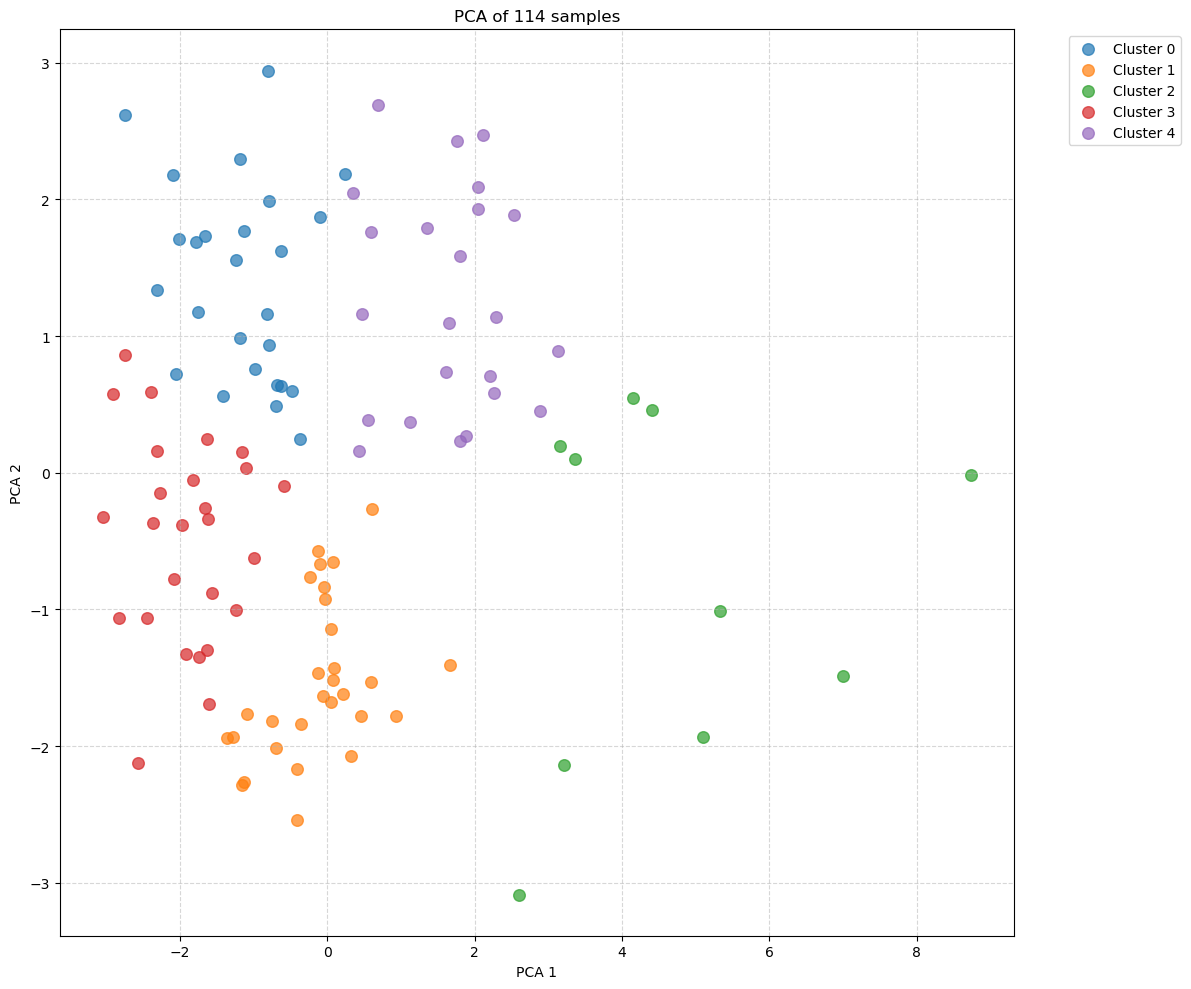

In [30]:
visualize_embeddings(concat_modality_embeddings(contents), method='pca', cluster_method='kmeans',cluster_params={"n_clusters": range(4,10)})

### Linear Probing of WES

In [31]:
os.environ["SCIPY_ARRAY_API"]="1"

In [76]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report
from sklearn.model_selection import cross_val_score

def linear_probing(X, y, model=LogisticRegression, cv=5):
    """
    Performs linear probing using a logistic regression model (or compatible classifier)
    to evaluate the predictive power of features with respect to a binary target.

    Parameters:
    ----------
    X : array-like or tensor
        Feature matrix. If `X` is a PyTorch tensor, it will be converted to a NumPy array.
    y : array-like or pandas Series
        Binary target labels. If `y` is a pandas Series, it will be converted to a NumPy array.
    model : sklearn-like classifier, optional
        A classifier class with scikit-learn interface. Defaults to `LogisticRegression`.
    cv : int, optional
        Number of cross-validation folds. Defaults to 5.

    Returns:
    -------
    acc : float
        Accuracy score on the held-out test set.
    roc : float
        ROC AUC score on the held-out test set.
    cr : str
        Text summary of the classification report.
    scores : ndarray
        Array of cross-validated ROC AUC scores.

    Notes:
    -----
    - Uses `train_test_split` to divide the data into 80% training and 20% test set.
    - The classifier is trained with class balancing (`class_weight='balanced'`) and max_iter=1000.
    - The model is evaluated using Accuracy, ROC AUC, and a detailed classification report.
    - Cross-validation scores are based on ROC AUC.
    """
    if hasattr(X, 'numpy'):
        X = X.detach().numpy()
    if hasattr(y, 'values'):
        y = y.values

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    clf = model(max_iter=1000, class_weight='balanced', C=10)
    clf.fit(X_train, y_train)

    y_pred = clf.predict(X_test)
    y_prob = clf.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_prob)
    cr = classification_report(y_test, y_pred)
    print("Accuracy:", acc)
    print("ROC AUC:", roc)
    print("Classification Report:\n", cr)

    scores = cross_val_score(clf, X, y, cv=cv, scoring='roc_auc')
    print("Mean ROC AUC (CV):", scores.mean())

    return acc, roc, cr, scores

X = rdy_contents['wes'] #clm_outputs[1][avail_mods[:,5]>0]
y = snvs_indels.loc[rdy_pids['wes'],:]["TP53"].astype(int)

linear_probing(X, y)

Accuracy: 0.4090909090909091
ROC AUC: 0.24479166666666669
Classification Report:
               precision    recall  f1-score   support

           0       0.67      0.38      0.48        16
           1       0.23      0.50      0.32         6

    accuracy                           0.41        22
   macro avg       0.45      0.44      0.40        22
weighted avg       0.55      0.41      0.44        22

Mean ROC AUC (CV): 0.48734693877551016


(0.4090909090909091,
 np.float64(0.24479166666666669),
 '              precision    recall  f1-score   support\n\n           0       0.67      0.38      0.48        16\n           1       0.23      0.50      0.32         6\n\n    accuracy                           0.41        22\n   macro avg       0.45      0.44      0.40        22\nweighted avg       0.55      0.41      0.44        22\n',
 array([0.58095238, 0.66190476, 0.31632653, 0.45918367, 0.41836735]))

##### Code to identify the indices present in the indexed list and filter the 
##### following list.

indexed_list = snvs_indels.index
input_tensor = clm_outputs[1]

present_indices = sorted(set(int(code[5:8]) for code in indexed_list))

tensor_indices = torch.tensor(
    [i - 1 for i in present_indices if i <= input_tensor.shape[0]]
    )

filtered_tensor = input_tensor[tensor_indices]

print(f"Original shape: {input_tensor.shape}")
print(f"Filtered shape: {filtered_tensor.shape}")

In [77]:
import seaborn as sns
import matplotlib.pyplot as plt

# List of genes to evaluate
genes = ["TP53", "EGFR", "PTEN", "NF1", "PIK3CA", "PIK3R1"]

results = []

# Run linear probing for each gene and collect metrics
for gene in genes:
    y = snvs_indels.loc[rdy_pids['wes'],:][gene].astype(int)
    print(X.shape, y.shape, gene)
    acc, roc, cr, scores = linear_probing(X, y)

    results.append({
        "Gene": gene,
        "Accuracy": round(acc, 4),
        "ROC AUC": round(roc, 4),
        "CV Mean ROC AUC": round(scores.mean(), 4),
        "CV Std ROC AUC": round(scores.std(), 4)
    })

results_df = pd.DataFrame(results)

torch.Size([107, 32]) (107,) TP53
Accuracy: 0.4090909090909091
ROC AUC: 0.24479166666666669
Classification Report:
               precision    recall  f1-score   support

           0       0.67      0.38      0.48        16
           1       0.23      0.50      0.32         6

    accuracy                           0.41        22
   macro avg       0.45      0.44      0.40        22
weighted avg       0.55      0.41      0.44        22

Mean ROC AUC (CV): 0.48734693877551016
torch.Size([107, 32]) (107,) EGFR
Accuracy: 0.5454545454545454
ROC AUC: 0.43162393162393164
Classification Report:
               precision    recall  f1-score   support

           0       0.58      0.85      0.69        13
           1       0.33      0.11      0.17         9

    accuracy                           0.55        22
   macro avg       0.46      0.48      0.43        22
weighted avg       0.48      0.55      0.47        22

Mean ROC AUC (CV): 0.4238235294117647
torch.Size([107, 32]) (107,) PTEN
Acc

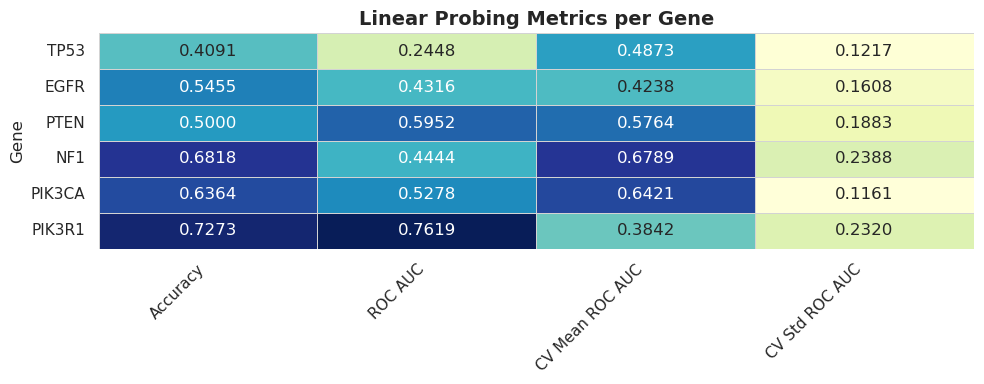

In [78]:
plt.figure(figsize=(10, 4))
sns.set(style="whitegrid")

sns.heatmap(
    results_df.set_index("Gene"),
    annot=True,
    fmt=".4f",
    cmap="YlGnBu",
    cbar=False,
    linewidths=0.6,
    linecolor="lightgray",
    annot_kws={"fontsize": 12}
)

plt.title("Linear Probing Metrics per Gene", fontsize=14, weight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


### Linear Probing of Bulk

In [79]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
import numpy as np

def linear_probing_regression(X, y, model=LinearRegression, cv=5):
    """
    Performs linear probing using a regression model (default is LinearRegression)
    to evaluate how well the features predict a continuous target variable.

    Parameters:
    ----------
    X : array-like or tensor
        Feature matrix. If `X` is a PyTorch tensor, it will be converted to a NumPy array.
    y : array-like or pandas Series
        Continuous target values. If `y` is a pandas Series, it will be converted to a NumPy array.
    model : sklearn-like regressor, optional
        A regression model class with scikit-learn interface. Defaults to `LinearRegression`.
    cv : int, optional
        Number of cross-validation folds. Defaults to 5.

    Returns:
    -------
    mse : float
        Mean Squared Error on the test set.
    mae : float
        Mean Absolute Error on the test set.
    r2 : float
        R² (coefficient of determination) score on the test set.
    scores : ndarray
        Array of cross-validated R² scores.

    Notes:
    -----
    - This function uses `train_test_split` to divide the dataset into 80% training and 20% testing.
    - It fits the regression model on the training data and evaluates performance on the test data.
    - Performance is assessed using MSE, MAE, and R² score.
    - It also performs k-fold cross-validation (default 5 folds) using the R² score.
    - If inputs are PyTorch tensors or pandas Series, they are automatically converted to NumPy arrays.
    """
    if hasattr(X, 'numpy'):
        X = X.detach().numpy()
    if hasattr(y, 'values'):
        y = y.values

    x_scaler = StandardScaler()
    y_scaler = StandardScaler()

    X = x_scaler.fit_transform(X.reshape(-1, X.shape[-1]) if X.ndim == 1 else X)
    y = y_scaler.fit_transform(y.reshape(-1, 1)).flatten()

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    reg = model()
    reg.fit(X_train, y_train)

    y_pred = reg.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print("Mean Squared Error (MSE):", mse)
    print("Mean Absolute Error (MAE):", mae)
    print("R² Score:", r2)

    scores = cross_val_score(reg, X, y, cv=cv, scoring='r2')
    print("Mean R² (CV):", scores.mean())

    return mse, mae, r2, scores

In [80]:
X_bulk = rdy_contents["bulk"] #clm_outputs[1][avail_mods[:,4]>0]
pids_bulk = [pid + '_mRNA' for pid in rdy_pids['bulk']]
y = bRNA_TPM.T.loc[pids_bulk,:][list(genes_ensembl_ids.values())[3]].astype(int)

linear_probing_regression(X_bulk, y)

Mean Squared Error (MSE): 2.7068709955161347
Mean Absolute Error (MAE): 1.2539607655115073
R² Score: -2.106979584245577
Mean R² (CV): -1.1176491848119858


(2.7068709955161347,
 1.2539607655115073,
 -2.106979584245577,
 array([-0.73212911, -1.54947347, -0.57718783, -1.16524372, -1.5642118 ]))

In [81]:
genes_ensembl_ids

{'EGFR': 'ENSG00000146648',
 'PDGFRA': 'ENSG00000134853',
 'NF1': 'ENSG00000196712',
 'CDKN2A': 'ENSG00000147889',
 'IDH1': 'ENSG00000138413',
 'MGMT': 'ENSG00000170430',
 'TERT': 'ENSG00000164362',
 'MDM2': 'ENSG00000135679',
 'CHI3L1': 'ENSG00000133048',
 'VEGFA': 'ENSG00000112715',
 'SOX2': 'ENSG00000181449',
 'OLIG2': 'ENSG00000205927',
 'CD44': 'ENSG00000026508'}

In [82]:
def find_key(dictionary, value_to_find):
    keys = [k for k, v in dictionary.items() if v == value_to_find]
    return keys[0]

In [83]:
genes = list(genes_ensembl_ids.values())

results = []
pids_bulk = [pid + '_mRNA' for pid in rdy_pids['bulk']]
for gene in genes:
    y = bRNA_TPM.T.loc[pids_bulk,:][gene].astype(float)
    mse, mae, r2, scores = linear_probing_regression(X_bulk, y, model=Lasso)

    results.append({
        "Gene": find_key(genes_ensembl_ids, gene),
        "MSE": round(mse, 4),
        "MAE": round(mae, 4),
        "R²": round(r2, 4),
        "CV Mean R²": round(scores.mean(), 4),
        "CV Std R²": round(scores.std(), 4)
    })

results_df = pd.DataFrame(results)


Mean Squared Error (MSE): 0.510100318835341
Mean Absolute Error (MAE): 0.6266962725430313
R² Score: -0.11018602186151982
Mean R² (CV): -0.12667250390562276
Mean Squared Error (MSE): 3.4463955597758833
Mean Absolute Error (MAE): 0.6721799693276003
R² Score: -0.05670902565362246
Mean R² (CV): -4.141529369847129
Mean Squared Error (MSE): 0.8698398823052452
Mean Absolute Error (MAE): 0.7513114170426137
R² Score: -0.017512895192808742
Mean R² (CV): -0.04439349773766379
Mean Squared Error (MSE): 0.8822115089108332
Mean Absolute Error (MAE): 0.7288788186361881
R² Score: -0.00787367574716824
Mean R² (CV): -0.1486835839264386
Mean Squared Error (MSE): 0.6257791329464268
Mean Absolute Error (MAE): 0.633310295152817
R² Score: -0.017924391236103787
Mean R² (CV): -0.024100406448857737
Mean Squared Error (MSE): 1.280697049876729
Mean Absolute Error (MAE): 0.8943174606011595
R² Score: -0.029814008848540574
Mean R² (CV): -0.1330871474146305
Mean Squared Error (MSE): 0.45695867066505497
Mean Absolute E

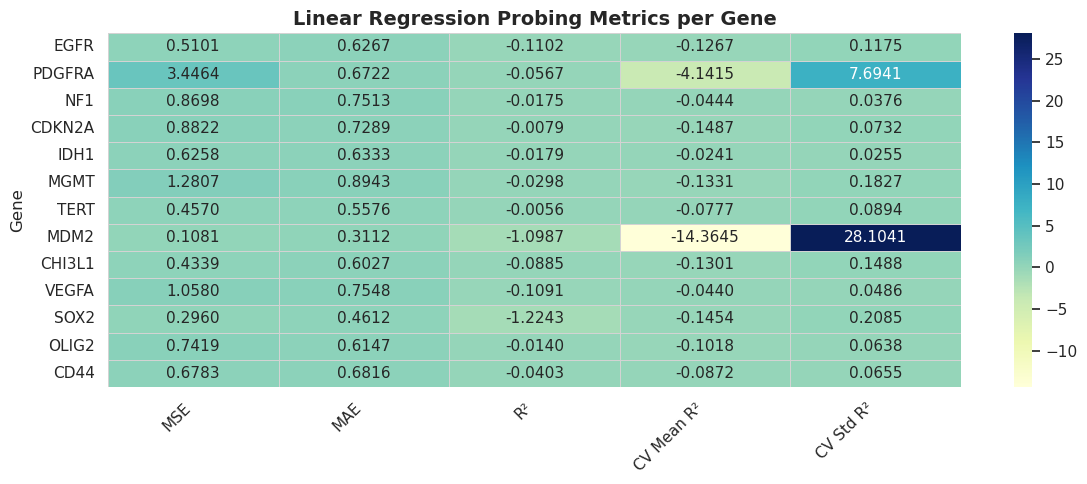

In [84]:
# Visualization
plt.figure(figsize=(12, 5))
sns.set(style="whitegrid")

# Ensure the correct numeric format and index setup
sns.heatmap(
    results_df.set_index("Gene"),
    annot=True,
    fmt=".4f",
    cmap="YlGnBu",
    cbar=True,
    linewidths=0.6,
    linecolor="lightgray",
    annot_kws={"fontsize": 11}
)

plt.title("Linear Regression Probing Metrics per Gene", fontsize=14, weight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Trustworthiness and Procrustes

In [41]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.manifold import trustworthiness
from scipy.spatial import procrustes

In [85]:
def evaluate_embedding_quality(X_raw, Y_raw, n_neighbors=5):
    """
    Evaluates the quality of the embedding Y with respect to the original binary input X.

    Parameters:
        X_raw (np.ndarray): Original binary input matrix (samples x features)
        Y_raw (np.ndarray): Continuous embedding (samples x embedding_dim)
        n_neighbors (int): Number of neighbors for trustworthiness computation

    Returns:
        dict containing metrics: MSE, R², trustworthiness, Procrustes disparity
    """
    # Scaling
    scaler_x = StandardScaler()
    scaler_y = StandardScaler()
    X_scaled = scaler_x.fit_transform(X_raw)
    Y_scaled = scaler_y.fit_transform(Y_raw)

    metrics = {}

    ## 1. Regression Y → X
    reg = Ridge()
    reg.fit(Y_scaled, X_scaled)
    X_pred = reg.predict(Y_scaled)

    metrics["mse"] = mean_squared_error(X_scaled, X_pred)
    metrics["r2"] = r2_score(X_scaled, X_pred)

    ## 2. Trustworthiness (local neighborhood preservation)
    try:
        trust = trustworthiness(X_scaled, Y_scaled, n_neighbors=n_neighbors)
        metrics["trustworthiness"] = trust
    except Exception as e:
        metrics["trustworthiness"] = f"Error: {str(e)}"

    ## 3. Procrustes (global geometric alignment)
    min_dim = min(X_scaled.shape[1], Y_scaled.shape[1])
    _, _, disparity = procrustes(X_scaled[:, :min_dim], Y_scaled[:, :min_dim])
    metrics["procrustes_disparity"] = disparity

    return metrics

In [92]:
y = bRNA_TPM.T.loc[pids_bulk,:].astype(int)

In [95]:
evaluate_embedding_quality(X_raw = X_bulk.cpu().detach().numpy(), Y_raw = y)

{'mse': 1.842107689186167e-09,
 'r2': 0.9999999981578923,
 'trustworthiness': np.float64(0.3929286858974359),
 'procrustes_disparity': np.float64(0.9722689519265335)}

## Let's combine everything in a convenient function call